# Summary analysis for selection history


- For this to work, you need to adapt the folder where raw data and metaData live.
- Also, you need to clone the jlsocialbehavior repository and create the environment jlsocial from the yml file.

In [1]:
import os

#define folders

# base = 'Y:\\Johannes\\b\\2019\\' This is the original base folder where the meta data was stored
nasPath='//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/' # adapt this to your own NAS D2c path
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/'  # Updated base folder. Metadata should live here.
codeDir = 'C:/Users/crodri19/OneDrive - Université de Lausanne/LarschPostDoc/analyses/selection_shoaling/jlsocialbehavior/' #adapt this to your code folder
metaFile='MetaData_JL_2019_consolidated_v2.xlsx'
ProcessingDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//'
outputDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_output//'

print('searching for meta info here: ' + metaFolder)

os.chdir(codeDir)

searching for meta info here: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms

%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
import fnmatch

import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
import glob
#import h5py
from datetime import datetime
import PythonMeta as PMA
from matplotlib.ticker import AutoLocator

import functions.matrixUtilities_joh as mu
import functions.notebookHelper as nh
import functions.metaTree as mt

import models.experiment as xp
import models.experiment_set as es
import functions.paperFigureProps as pfp
pfp.paper()

using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


In [3]:
info=pd.read_excel(metaFolder+metaFile, sheet_name='AllExp')
ix=(info.stimulusProtocol=='selection')#&(info.date.isin(['2019-08-05','2019-08-06','2019-09-25','2019-10-04']))
info=info[ix].reset_index(drop=True)
info

,date,stimulusProtocol,set,Line,generation,repeat,selected,path,folder,setup,comments,anNr,start,end,rnaSet
0,2019-07-18,selection,a,TL3,1.0,1.0,0.0,Johannes/b/selection/,20190718_01_35Animals_dn_TlSel3F1,dn,NaN,176:210,176,210,x
1,2019-07-18,selection,a,TL3,1.0,1.0,0.0,Johannes/b/selection/,20190718_02_35Animals_up_TlSel3F1,up,NaN,211:245,211,245,x
2,2019-07-19,selection,a,In3,1.0,1.0,0.0,Johannes/b/selection/,20190719_01_35Animals_dn_InSel3F1,dn,NaN,246:280,246,280,x
3,2019-07-19,selection,a,In3,1.0,1.0,0.0,Johannes/b/selection/,20190719_02_35Animals_up_InSel3F1,up,NaN,281:315,281,315,x
4,2019-08-05,selection,s,TL3,1.0,2.0,1.0,Johannes/b/selection/,20190805_01_35Animals_dn_TlSel3F1,dn,NaN,316:350,316,350,x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2023-05-16,selection,a,TL3,6.0,1.0,1.0,Johannes/b/selection/,20230516_01_35Animals_dn_TLSel3F6,dn,NaN,5275:5309,5275,5309,x
104,2023-05-16,selection,a,TL3,6.0,1.0,1.0,Johannes/b/selection/,20230516_02_35Animals_up_TLSel3F6,up,NaN,5310:5344,5310,5344,x
105,2025-01-28,selection,a,TL1,9.0,1.0,1.0,Johannes/b/selection/,20250128_01_35Animals_dn_TLSel1F9,s1,NaN,5345:5379,5345,5379,x
106,2025-05-13,selection,a,TL3,7.0,1.0,1.0,Johannes/b/selection/,20250513_01_35Animals_s1_TLSel3F7,s1,NaN,5380:5414,5380,5414,x


In [4]:
infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd'])
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%Y%m%d')
#infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%Y%m%d')
infoAn.tail()

C:\Users\crodri19\AppData\Local\Temp\ipykernel_23176\1061432783.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd'])


,anNr,line,bg,cohort,generation,repeat,genotype,bd,listBD,year,month,day,sex,conc
5514,5515,TLN,30,bout,NaN,NaN,wt,2025-03-10 09:00:00+00:00,2025-03-10,2025,3,10,NaN,2025-3-10-09-00
5515,5516,TLN,31,bout,NaN,NaN,wt,2025-03-10 09:00:00+00:00,2025-03-10,2025,3,10,NaN,2025-3-10-09-00
5516,5517,TLN,32,bout,NaN,NaN,wt,2025-03-10 09:00:00+00:00,2025-03-10,2025,3,10,NaN,2025-3-10-09-00
5517,5518,TLN,33,bout,NaN,NaN,wt,2025-03-10 09:00:00+00:00,2025-03-10,2025,3,10,NaN,2025-3-10-09-00
5518,5519,TLN,34,inv,NaN,NaN,wt,2025-03-10 09:00:00+00:00,2025-03-10,2025,3,10,NaN,2025-3-10-09-00


In [5]:
infoAn.genotype.unique()

array(['nd', 'hi', 'lo', 'wt', 'cross', 'h', 'm', 'inx', 'a', 'x', 'dark',
       'light', 'mid', 'cont', 'bout', 'invi', 'fish', 'wp', 'mn', 'wn',
       'mp', 'hp', 'abl', 'ctr', 'none', 'e', 'p', 'n', 'no', 'o', '3n',
       '4n', '3p', '4p', '1e', 'mres', 'da', 'hres', 'li', 'mlres',
       'wres', '1n', '2n', '2p', '1p', 'w', 'ep', 1, 2, 3, 4, 6, 5,
       'todo'], dtype=object)

In [6]:
# collect meta information and save to new csv file for batch processing

aviPath=[]
posPath=[]
PLPath=[]
expTime = []
birthDayAll=[]
anIDsAll=[]
camHeightAll=[]

camHeight=[105,180] # these are outdated values, but we keep them for compatibility with old data


for index,row in info.iterrows():

    startDir=nasPath+row.path+row.folder+'\\' # I removed the nas path from the metadata to make this easier to adapt to different computers
    print('processing: ' + startDir)
    if not os.path.exists(startDir):
        print('WARNING: path does not exist: ' + startDir)
        continue

    
    posPath.append(glob.glob(startDir+'PositionTxt*')[0]) #this is the trajectory file
    PLPath.append(glob.glob(startDir+'PL*')[0]) # this is the pair list file
    
    head, tail = os.path.split(posPath[-1])
    currTime='dummy' #datetime.strptime(tail[-23:-4], '%Y-%m-%dT%H_%M_%S')
    expTime.append(currTime)
    
    camHeightAll.append(camHeight[('_dn_' in head)*1]) ######### this needs to be adapted for new data, since the camHeight is not stored in the meta data anymore.
    
    anNrs=row.anNr #Note that anNrs are 1 based!
    if ':' in anNrs:
        a,b=anNrs.split(sep=':')
        anNrs=np.arange(int(a),int(b)+1)
    else:
        anNrs=np.array(anNrs.split()).astype(int)
        
    anIDs=anNrs #-1 no more 0-based since using pandas merge to find animal numbers
    anIDsAll.extend(anIDs)

    bd=infoAn[infoAn.anNr.isin(anIDs)].bd.values.astype(str) # get birth dates of animals in this experiment
    #bd=infoAn.bd.values[anIDs-1] #a bit dirty to use anIDs directly here. Should merge
    birthDayAll.append(' '.join(list(bd)))

info['camHeight']=camHeightAll
info['txtPath']=posPath
info['pairList']=PLPath
info['aviPath']='default'
info['birthDayAll']=birthDayAll
info['epiDur'] = 5      # duration of individual episodes (default: 5 minutes)
info['episodes'] = 24   # number of episodes to process: -1 to load all episodes (default: -1)
info['inDish'] = 10#np.arange(len(posPath))*120     # time in dish before experiments started (default: 10)
info['arenaDiameter_mm'] = 70 # arena diameter (default: 100 mm)
info['minShift'] = 60 # minimum number of seconds to shift for control IAD
info['episodePLcode'] = 0 # flag if first two characters of episode name encode animal pair matrix (default: 0)
info['recomputeAnimalSize'] = 0 # flag to compute animals size from avi file (takes time, default: 1)
info['SaveNeighborhoodMaps'] = 0 # flag to save neighborhood maps for subsequent analysis (takes time, default: 1)
info['computeLeadership'] = 0 # flag to compute leadership index (takes time, default: 1)
info['ComputeBouts'] = 1 # flag to compute swim bout frequency (takes time, default: 1)
#info['set'] = np.arange(len(posPath))   # experiment set: can label groups of experiments (default: 0)
info['ProcessingDir']=ProcessingDir
info['outputDir']=outputDir
info['expTime']=expTime
info['readLim'] = 24*5*60*30+11

processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190718_01_35Animals_dn_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190718_02_35Animals_up_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190719_01_35Animals_dn_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190719_02_35Animals_up_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190805_01_35Animals_dn_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190805_02_35Animals_up_TlSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190806_01_35Animals_dn_InSel3F1\
processing: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Johannes/b/selection/20190806_02

In [7]:
csvFile=os.path.join(ProcessingDir,'processingSettings.csv')
info.to_csv(csvFile,encoding='utf-8')
info.tail()


,date,stimulusProtocol,set,Line,generation,repeat,selected,path,folder,setup,...,minShift,episodePLcode,recomputeAnimalSize,SaveNeighborhoodMaps,computeLeadership,ComputeBouts,ProcessingDir,outputDir,expTime,readLim
103,2023-05-16,selection,a,TL3,6.0,1.0,1.0,Johannes/b/selection/,20230516_01_35Animals_dn_TLSel3F6,dn,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
104,2023-05-16,selection,a,TL3,6.0,1.0,1.0,Johannes/b/selection/,20230516_02_35Animals_up_TLSel3F6,up,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
105,2025-01-28,selection,a,TL1,9.0,1.0,1.0,Johannes/b/selection/,20250128_01_35Animals_dn_TLSel1F9,s1,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
106,2025-05-13,selection,a,TL3,7.0,1.0,1.0,Johannes/b/selection/,20250513_01_35Animals_s1_TLSel3F7,s1,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
107,2025-05-13,selection,a,TL3,7.0,1.0,1.0,Johannes/b/selection/,20250513_02_35Animals_s2_TLSel3F7,s2,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011


In [8]:
rereadData=1
if rereadData:
    def readExperiment(keepData=True):
        tmp=es.experiment_set(csvFile=csvFile,MissingOnly=True)
        if keepData:
            return tmp
        else:
            return 1

    expSet=readExperiment(keepData=False)

False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-18T11_10_59*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-18T11_36_23*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-19T10_46_57*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-07-19T11_04_05*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing//PositionTxt_allROI2019-08-05T11_10_03*siSummary*.csv
False False //nasdcsr.unil.ch/RECHE

In [9]:
csvPath = []
for f in [mu.splitall(x)[-1][:-4] for x in info.txtPath]:
    csvPath.append(glob.glob(ProcessingDir+f+'*siSummary*.csv')[0])

df=pd.DataFrame()
i=0
for fn in csvPath:
    print(fn)
    tmp=pd.read_csv(fn,index_col=0,sep=',')
    tmp.animalSet=i
    tmp.animalIndex=tmp.animalIndex+((i)*35)
    tmp.animalIndex=np.array(anIDsAll)[tmp.animalIndex]
    df=pd.concat([df,tmp])
    i+=1

df.tail(10)



//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-18T11_10_59_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-18T11_36_23_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-19T10_46_57_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-07-19T11_04_05_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//shoaling_selection//ShoalHist_temp_processing\PositionTxt_allROI2019-08-05T11_10_03_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,stimulusProtocol,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t
830,107,5440,25,35,0.240135,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,5.532347,4.122444,4.036911,14.421913,1.200000,0,0.0,0.0
831,107,5441,26,35,0.195602,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,7.353346,5.996042,4.389137,14.962376,0.700000,0,0.0,0.0
832,107,5442,27,35,0.304878,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,6.530327,5.167807,5.012194,13.725271,1.133333,0,0.0,0.0
833,107,5443,28,35,0.193945,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,5.281934,3.789855,8.266055,11.536077,1.100000,0,0.0,0.0
834,107,5444,29,35,0.174775,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,6.371003,5.100278,8.997386,15.848176,1.066667,0,0.0,0.0
835,107,5445,30,35,0.483777,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,6.511778,4.726394,6.843787,16.977909,0.900000,0,0.0,0.0
836,107,5446,31,35,0.148422,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,4.948088,2.995138,8.294036,13.306543,1.400000,0,0.0,0.0
837,107,5447,32,35,0.526634,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,6.026397,4.026653,4.893475,17.118221,0.800000,0,0.0,0.0
838,107,5448,33,35,0.196420,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,5.164562,3.081970,7.881589,13.247571,1.066667,0,0.0,0.0
839,107,5449,34,35,0.435673,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,selection,19.0,6.506015,4.747697,6.379774,14.210854,0.766667,0,0.0,0.0


In [10]:

df['episode']=[x.strip().replace('_','') for x in df['episode']]
df=pd.merge(df,infoAn[['anNr','line','genotype','bg','cohort','generation','repeat']],left_on='animalIndex',right_on='anNr',how='left')
df=pd.merge(df,info[['date','selected','set','setup','rnaSet']],left_on='animalSet',right_on=info.index,how='left')
df['setup'] = info['setup'].values[df['animalSet'].values]
print('df shape',df.shape)
df['lineSet']=[x+'_'+y for x,y in zip(df.line, df.date)]


df.tail(10)

df shape (108885, 33)


,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,bg,cohort,generation,repeat,date,selected,set,setup,rnaSet,lineSet
108875,107,5440,25,35,0.240135,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108876,107,5441,26,35,0.195602,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108877,107,5442,27,35,0.304878,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108878,107,5443,28,35,0.193945,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108879,107,5444,29,35,0.174775,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108880,107,5445,30,35,0.483777,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108881,107,5446,31,35,0.148422,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108882,107,5447,32,35,0.526634,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108883,107,5448,33,35,0.196420,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13
108884,107,5449,34,35,0.435673,02k20f,207000,125.0,23,2025-05-13 14:17:59,...,TL,3,7,1,2025-05-13,1.0,a,s2,x,TLSel3_7_2025-05-13


In [11]:
sns.set_palette('viridis',3)
co=sns.color_palette("viridis", 3)
idx=(df['inDishTime']<240) & (df['inDishTime']>80)
dfDR=df[idx]
dfEpiAn=dfDR.groupby(['episode','animalIndex','line','setup','genotype','date','lineSet','bg','cohort','generation','repeat','set','rnaSet'],sort=True).mean(numeric_only=True).reset_index()

In [12]:
dfEpiAn.head()

,episode,animalIndex,line,setup,genotype,date,lineSet,bg,cohort,generation,...,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr,selected
0,01k01f,176,TLSel3,dn,hi,2019-07-18,TLSel3_2019-07-18,TL,3,1,...,4.999772,3.614362,6.834031,17.384942,1.008333,0.0,0.0,0.0,176.0,0.0
1,01k01f,177,TLSel3,dn,lo,2019-07-18,TLSel3_2019-07-18,TL,3,1,...,5.186201,3.820046,7.688285,12.483362,0.866667,0.0,0.0,0.0,177.0,0.0
2,01k01f,178,TLSel3,dn,hi,2019-07-18,TLSel3_2019-07-18,TL,3,1,...,4.788171,3.507877,5.246813,19.657816,1.000000,0.0,0.0,0.0,178.0,0.0
3,01k01f,179,TLSel3,dn,lo,2019-07-18,TLSel3_2019-07-18,TL,3,1,...,5.930552,4.794204,9.179189,16.863273,0.908333,0.0,0.0,0.0,179.0,0.0
4,01k01f,180,TLSel3,dn,hi,2019-07-18,TLSel3_2019-07-18,TL,3,1,...,4.800645,3.548137,7.513334,16.137740,0.916667,0.0,0.0,0.0,180.0,0.0


In [13]:

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x))

x=np.random.random(100)

def ci95(x):
    return np.nanmean(x)-sms.DescrStatsW(x[np.isfinite(x)]).tconfint_mean()[0]

print('std of uniform = 0.2886751345948129. STDdata:',np.std(x), 'semData:',sem(x),'samples:',x.shape) 
print('ci95:',ci95(x))

std of uniform = 0.2886751345948129. STDdata: 0.29690975123631547 semData: 0.029840552771170266 samples: (100,)
ci95: 0.059210130650945436


In [14]:
dfPlot=(df.groupby(['inDishTime','episode','genotype','lineSet']).si.agg(['mean','std',sem,ci95])
    .unstack()
    .stack(dropna=True)
    .reset_index())

dfPlot.head()

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:228: RuntimeWarning: invalid value encountered in scalar divide
  return std / np.sqrt(self.sum_weights - 1)
C:\Users\crodri19\AppData\Local\Temp\ipykernel_23176\3738759538.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


,inDishTime,episode,genotype,lineSet,mean,std,sem,ci95
0,10.0,01k01f,cross,TL3Hi21fxTL3Lo21m_2019-12-18,0.101201,0.156565,0.041844,0.090398
1,10.0,01k01f,cross,TL3Hi21mxTL3Lo21f_2019-12-18,0.059792,0.110234,0.029461,0.063647
2,10.0,01k01f,cross,TL3Hi23xTL3Lo23_2019-12-09,0.049536,0.070192,0.018760,0.040527
3,10.0,01k01f,cross,TL3Hi24xTL3Lo24_2019-12-10,0.084265,0.117813,0.022265,0.045683
4,10.0,01k01f,cross,TL3Hi2xIn3Hi2_2019-11-11,0.087597,0.098156,0.031040,0.070217


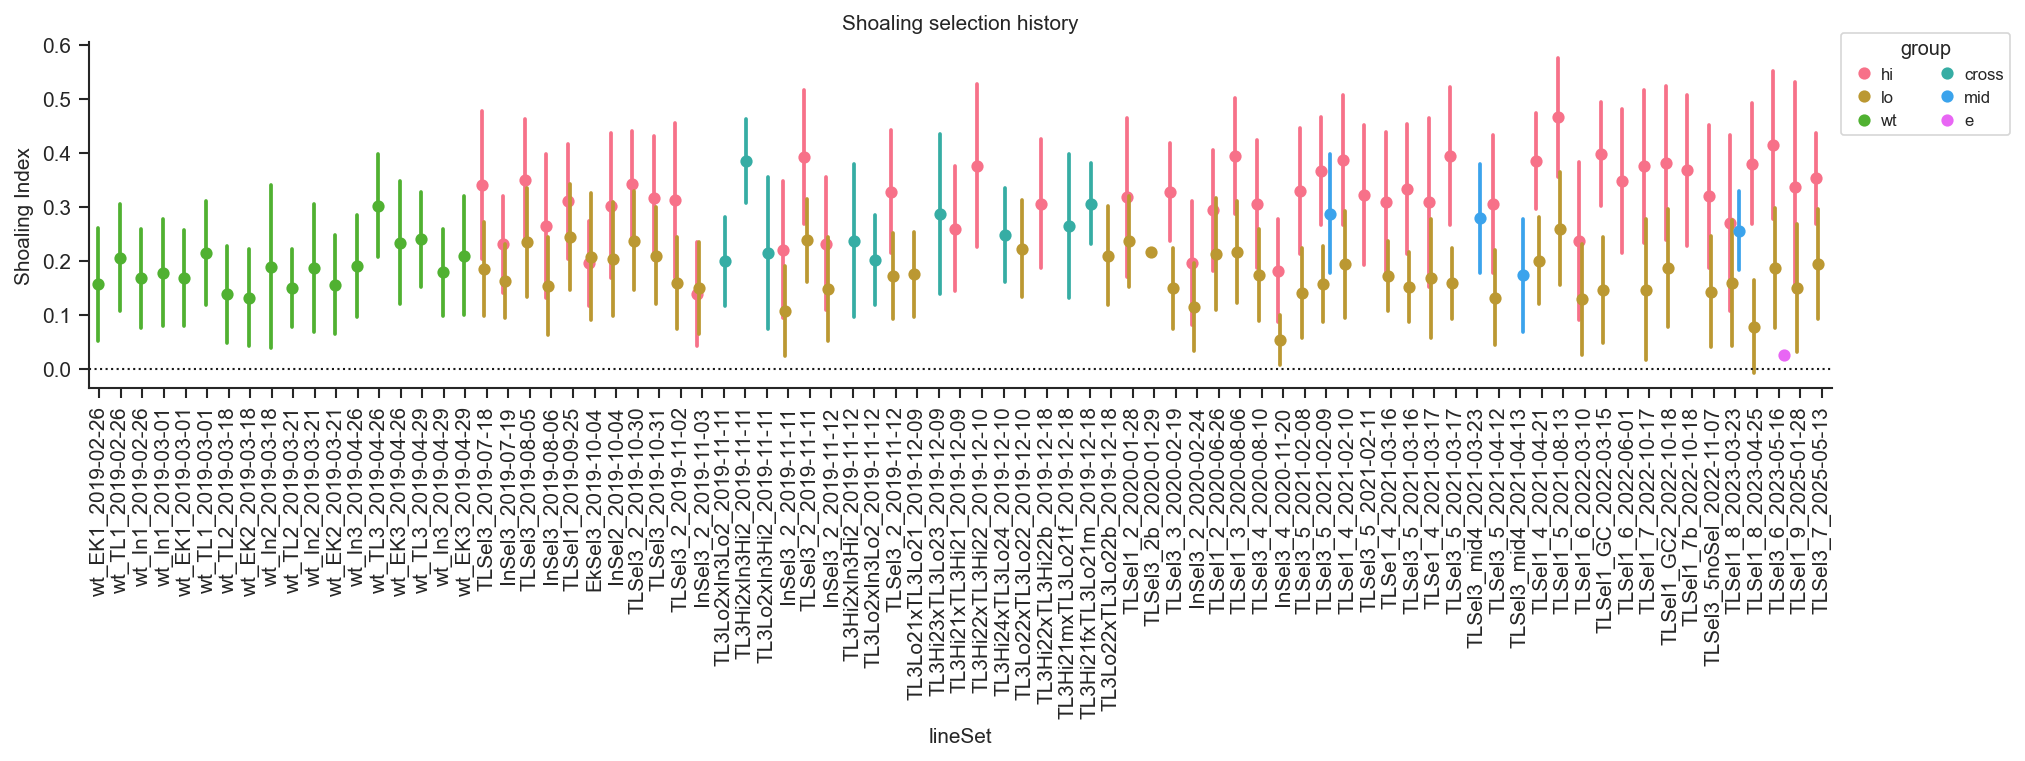

In [15]:
order = dfEpiAn[dfEpiAn.episode=='02k20f'].groupby('lineSet')['date'].first().sort_values().index.tolist()

fig, axes = plt.subplots(figsize=(15,3))

sns.pointplot(data=dfEpiAn[dfEpiAn.episode=='02k20f'],
              x='lineSet',
              y='si',
              order = order,
              hue='genotype',
              
             linestyle='none',
             errorbar='sd',
             dodge=.5)
sns.despine()

axes.set_ylabel('Shoaling Index')
axes.axhline(0,ls=':',color='k')
axes.set_title('Shoaling selection history');
plt.legend(title='group',ncol=2,handletextpad=0,bbox_to_anchor=(1, 1.05))
plt.xticks(rotation=90);

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

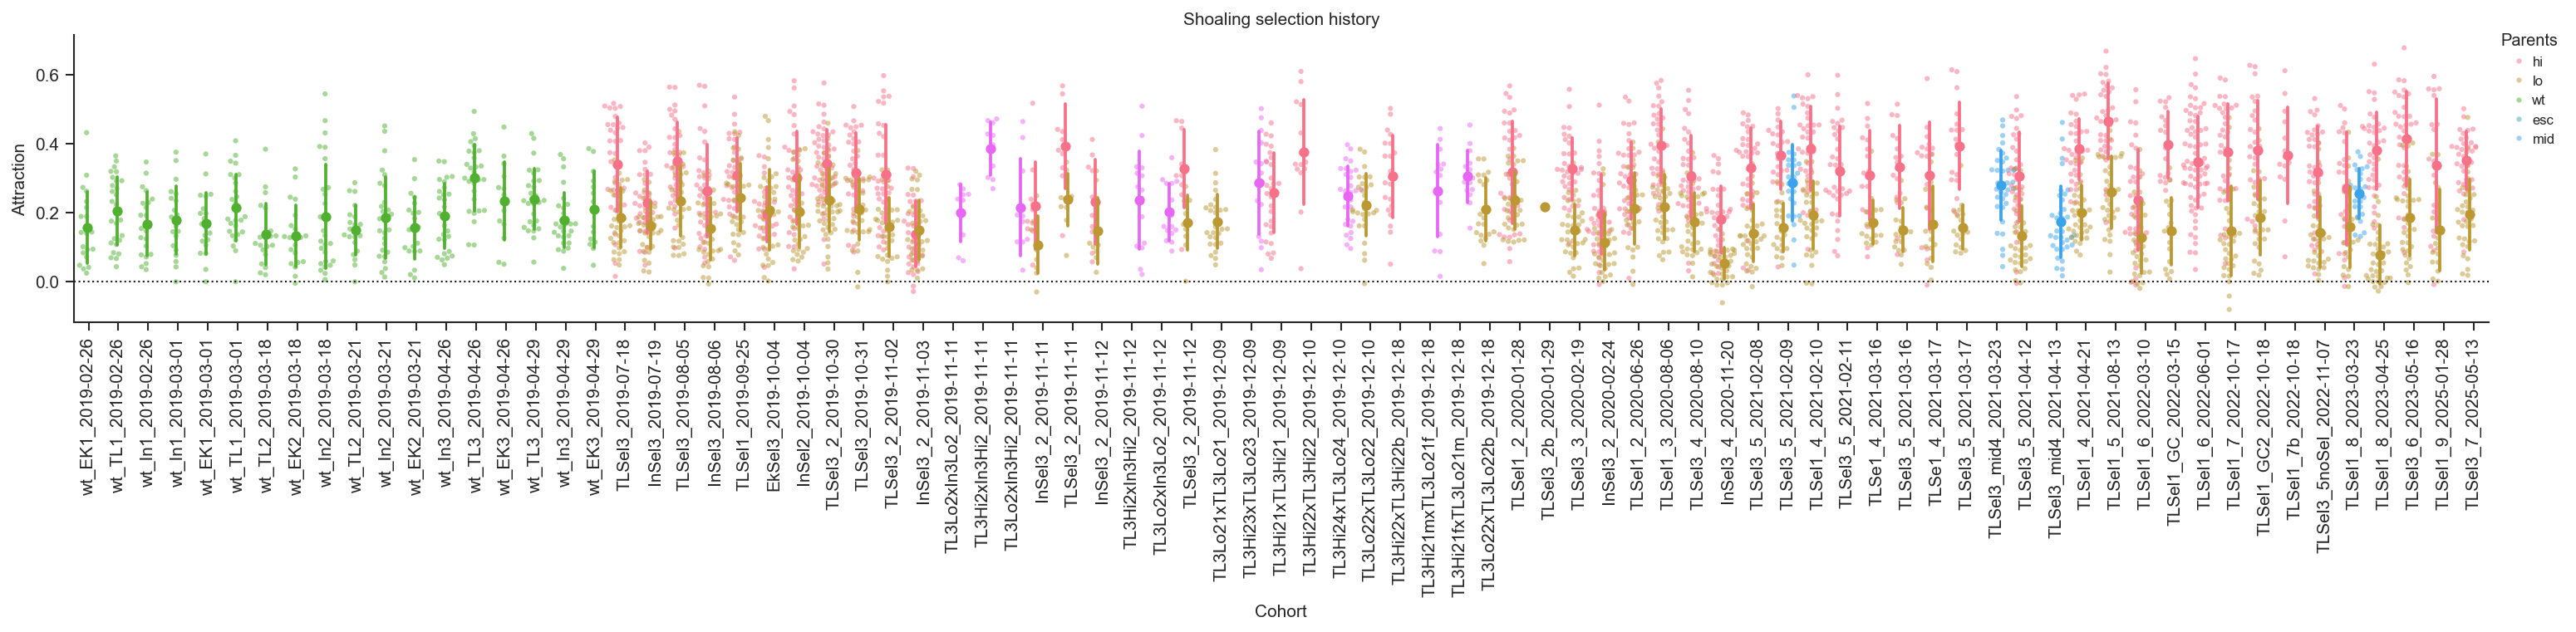

In [16]:
order = dfEpiAn[dfEpiAn.episode=='02k20f'].groupby('lineSet')['date'].first().sort_values().index.tolist()

fig, axes = plt.subplots(figsize=(25, 3))
ix=(dfEpiAn.episode=='02k20f')#&(~dfEpiAn.lineSet.str.contains('_2_'))

selDat=dfEpiAn[ix]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              order=order,
              zorder=-1,
              dodge=.5,
              size=3,
              alpha=.5,
              #order=allCat,
             hue_order=["hi", "lo",'wt','esc','mid','cross'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              order=order,
              hue='genotype',
              dodge=.5,
              linestyle='none',
              errorbar='sd',
              hue_order=["hi", "lo",'wt','esc','mid','cross'])


sns.despine()

axes.set_ylabel('Attraction')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Shoaling selection history');


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

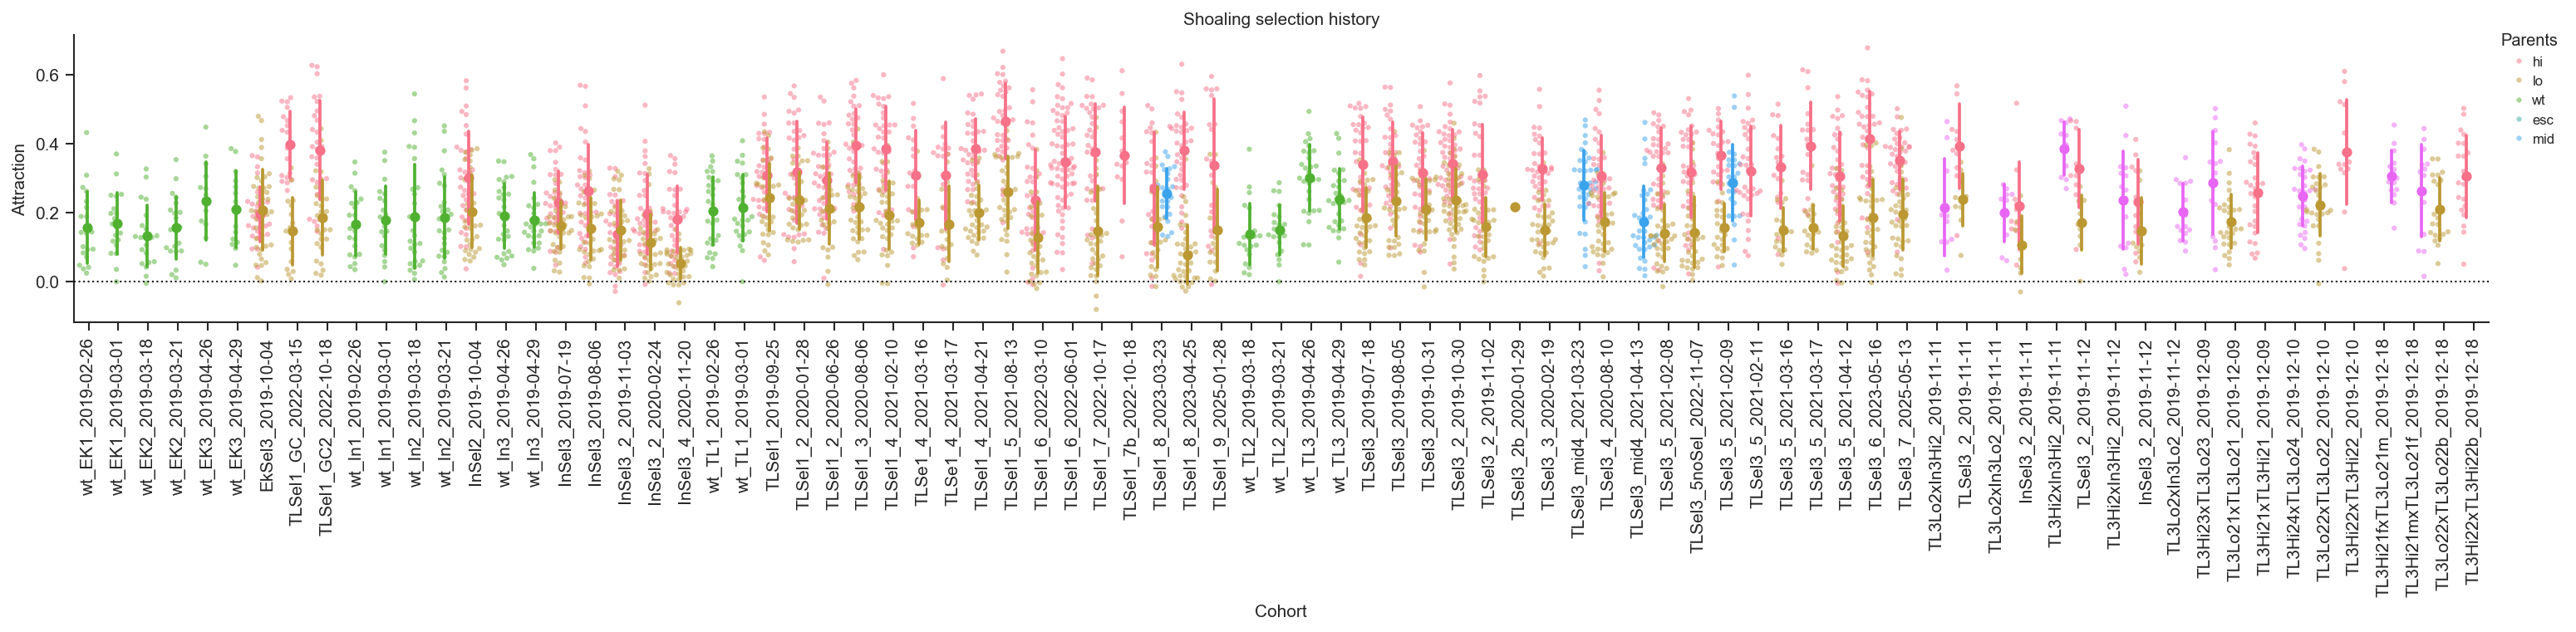

In [17]:

fig, axes = plt.subplots(figsize=(25, 3))
ix=(dfEpiAn.episode=='02k20f')
selDat=dfEpiAn[ix]


order = selDat.sort_values(['bg', 'cohort', 'generation', 'repeat'])['lineSet'].unique().tolist()
allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              order=order,
              zorder=-1,
              dodge=.5,
              size=3,
              alpha=.5,
              #order=allCat,
             hue_order=["hi", "lo",'wt','esc','mid','cross'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              order=order,
              hue='genotype',
              dodge=.5,
              linestyle='none',
              errorbar='sd',
              hue_order=["hi", "lo",'wt','esc','mid','cross'])


sns.despine()

axes.set_ylabel('Attraction')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Shoaling selection history');


In [18]:
def plot_selection_history(dfEpiAn, episode=None, bg=None, cohort=None, selected=None, splitSetup=False, figsize=(5, 3), forceLabel=None):
    fig, axes = plt.subplots(figsize=figsize)

    ix = pd.Series([True] * len(dfEpiAn), index=dfEpiAn.index)
    if episode is not None:
        ix &= (dfEpiAn.episode == episode)
    if bg is not None:
        ix &= (dfEpiAn.bg == bg)
    if cohort is not None:
        ix &= (dfEpiAn.cohort == cohort)
    if selected is not None:
        ix &= (dfEpiAn.selected == selected)

    if forceLabel is not None:
        lineTxt = forceLabel
    else:
        lineTxt = f"{bg}{cohort}" if bg is not None and cohort is not None else ""

    selDat = dfEpiAn[ix]   

    # if splitSetup: lineSet will be concatenated with setup to create a unique identifier for plotting.
    if splitSetup:
        selDat = selDat.copy()
        selDat['lineSet'] = selDat['lineSet'].astype(str) + '_' + selDat['setup'].astype(str)


    order = selDat.sort_values(['bg', 'cohort', 'generation', 'repeat'])['lineSet'].unique().tolist()

    sns.swarmplot(
        data=selDat,
        x='lineSet',
        y='si',
        hue='genotype',
        order=order,
        zorder=-1,
        dodge=.5,
        size=3,
        alpha=.5,
        hue_order=["hi", "lo", 'wt', 'esc', 'mid', 'cross']
    )

    sns.pointplot(
        data=selDat,
        x='lineSet',
        y='si',
        order=order,
        hue='genotype',
        dodge=.5,
        linestyle='none',
        errorbar='sd',
        hue_order=["hi", "lo", 'wt', 'esc', 'mid', 'cross']
    )

    sns.despine()
    axes.set_ylabel('Attraction')
    axes.set_xlabel('Cohort')
    axes.axhline(0, ls=':', color='k')
    plt.xticks(rotation=90)

    handles, labels = axes.get_legend_handles_labels()
    plt.legend(
        handles[:5], labels[:5], title='Parents', ncol=1, handletextpad=0,
        bbox_to_anchor=(1, 1.05), frameon=False
    )
    plt.title('Shoaling selection history ' + lineTxt)
    return fig, axes


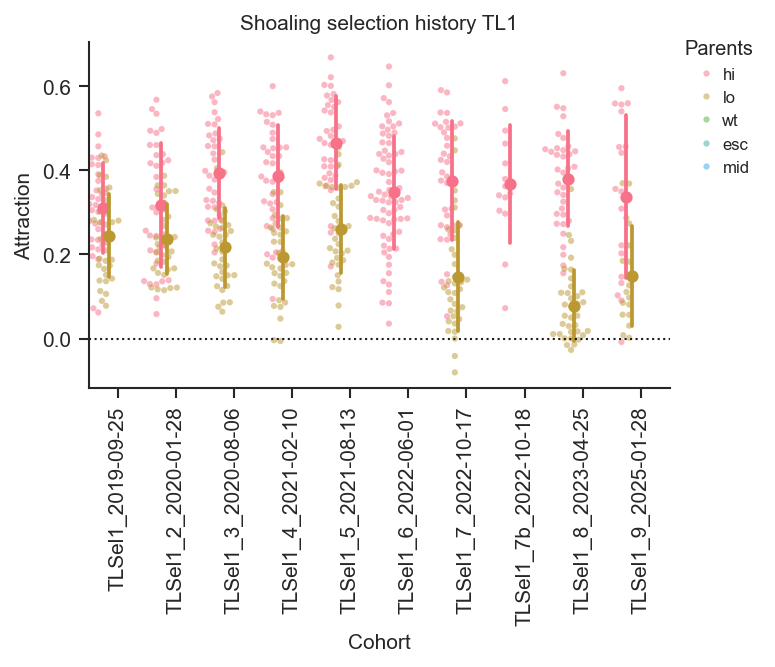

In [19]:
plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='1', selected=1);

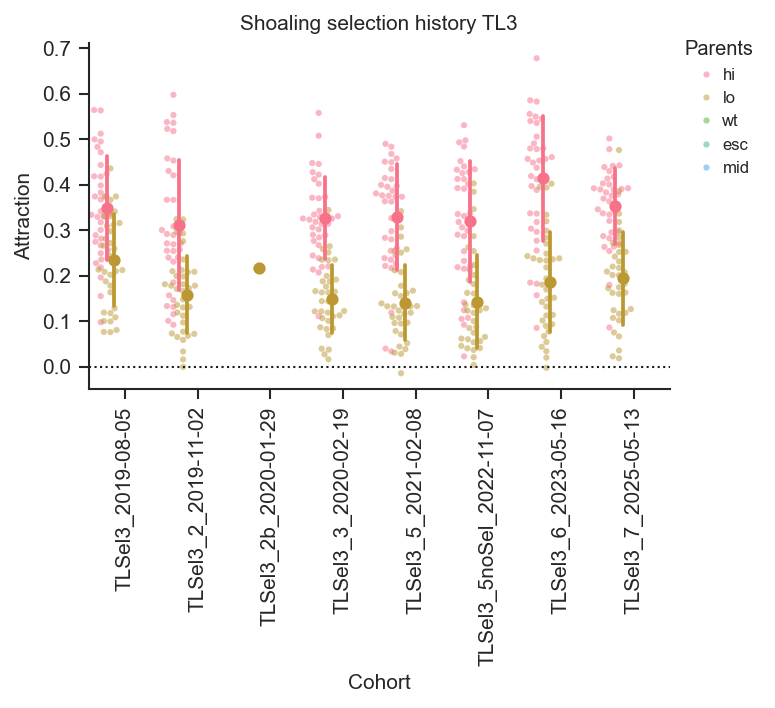

In [20]:
plot_selection_history(dfEpiAn, episode='02k20f', bg='TL', cohort='3', selected=1);

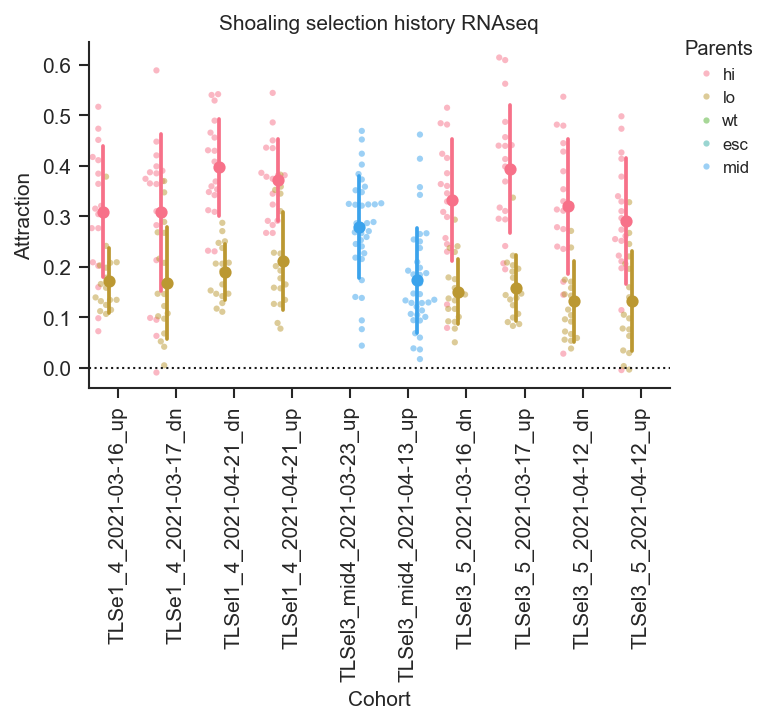

In [21]:
subset=dfEpiAn[dfEpiAn.rnaSet.isin(['a','b'])]
plot_selection_history(subset, 
                       episode='02k20f', 
                       bg='TL', 
                       selected=0, 
                       splitSetup=True,
                       forceLabel='RNAseq');